# Quantum logical-T State Encoding with a Color Code

In [224]:
%load_ext autoreload
%autoreload 2

from tsim import Circuit
import sinter
import numpy as np
import matplotlib.pyplot as plt
from tesseract_decoder import tesseract, TesseractSinterDecoder
from utils.no_decoder import NoDecoder
from utils.binomial_standard_error import binomial_standard_error as stat_err

This tutorial showcases the basic functionality of **Tsim**.

tsim is a circuit sampler for Clifford+T circuits, based on stabilizer rank decomposition and ZX-calculus techniques. It closely follows the API of stim and directly uses stim's circuit format.

In contrast to Stim, Tsim supports `T` and `T_DAG` instructions.

The following circuit demonstrates this by preparing and measuring the state
$$H\,T\,|+\rangle
= e^{i\pi/8}\Big[\cos\!\left(\tfrac{\pi}{8}\right)\,|0\rangle
\;-\; i\,\sin\!\left(\tfrac{\pi}{8}\right)\,|1\rangle\Big].$$

In [225]:
c = Circuit("""
    RX 0
    T 0
    H 0
    M 0
    """)
c.diagram("timeline-svg", height=150)

To sample from this circuit, we first compile it into a sampler:

In [226]:
sampler = c.compile_sampler()

We can now sample bitstrings from the measurement instructions:

In [227]:
sampler.sample(shots=10)

array([[False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False]])

Let's run a large number of shots to estimate the probability of measuring `1`.

In [228]:
samples = sampler.sample(shots=10_000_000, batch_size=1_000_000)
int(np.count_nonzero(samples)) / len(samples)

0.1464866

As expected, the probability is close to $\sin(\pi/8)^2 \approx 0.1464$.

## Detectors and Observables
Next, we consider a more complex example: an encoding circuit for the [[7,1,3]] Steane code. We will prepare logical T-state.

The Standard T-State is usually written as a rotation around the Z-axis applied to a $|+\rangle$ state:$$|T\rangle = \frac{|\bar{0}\rangle + e^{i\pi/4}|\bar{1}\rangle}{\sqrt{2}}$$ 

We will prepare state which take that standard $|T\rangle$ state and apply a logical Hadamard gate ($H_L$) to it.
If you apply the math of a Hadamard gate to $\frac{|\bar{0}\rangle + e^{i\pi/4}|\bar{1}\rangle}{\sqrt{2}}$, it algebraically expands into the exact formula shown below

 This circuit prepares the logical state

$$\frac{1}{2}\Big[(1 + e^{i\pi/4})|\bar{0}\rangle + (1 - e^{i\pi/4})|\bar{1}\rangle\Big]$$

Equivalent to  $R_x(\pi/4)$ to the logical $|\bar{0}\rangle$ , which is :
$$\cos(\pi/8)|\bar{0}\rangle - i\sin(\pi/8)|\bar{1}\rangle$$

Code below  prepares the exact non-Clifford logical magic state  ($H|T\rangle_L$), weaves it into a 7-qubit block, and then measures it to verify the encoding.

In [229]:
c = Circuit("""
    RX 6
    T 6
    H 6
    R 0 1 2 3 4 5
    SQRT_Y_DAG 0 1 2 3 4 5
    CZ 1 2 3 4 5 6
    SQRT_Y 6
    CZ 0 3 2 5 4 6
    SQRT_Y 2 3 4 5 6
    CZ 0 1 2 3 4 5
    SQRT_Y 1 2 4
    X 3
    TICK
    M 0 1 2 3 4 5 6
    DETECTOR rec[-7] rec[-6] rec[-5] rec[-4]  # These lines represent the 3 $Z$-stabilizers of the Steane code.
    DETECTOR rec[-6] rec[-5] rec[-3] rec[-2]  # ... If the encoding circuit was perfectly noiseless, all three of these parities will equal 0.
    DETECTOR rec[-5] rec[-4] rec[-3] rec[-1]  # ... If noise occurred during the CZ gates, one or more detectors will fire to alert your decoder
    OBSERVABLE_INCLUDE(0) rec[-7] rec[-6] rec[-2]  # this tracks the logical payload
    """)

tsim supports multiple visualization methods. The default makes use of `stim`'s "timeline-svg" visualization function:

In [230]:
c.diagram(height=350)

Tsim also supports visualization as a ZX diagram, where measurement vertices are annotated with `rec[i]`, and detector and observable vertices are annotated with `det[i]` and `obs[i]`, respectively.

In [231]:
c.diagram("pyzx");

To sample detection events and logical observables, we can compile a detector sampler, similar to `stim`.

In [232]:
det_sampler = c.compile_detector_sampler(seed=1)

In [233]:
det_samples, obs_samples = det_sampler.sample(shots=100_000, separate_observables=True)
print(det_samples[:5])
print(obs_samples[:5])

[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]]
[[False]
 [False]
 [False]
 [ True]
 [False]]


Since the circuit is just a logical encoding of the 1-qubit circuit from the beginning of the tutorial, the logical observable should behave exactly like the physical qubit in the first example, i.e., the observable should be 1 with probability $\sin(\pi/8)^2 \approx 0.1464$.

Additionally, since the circuit is noiseless, we should not observe any non-zero detection events:

In [234]:
assert np.count_nonzero(det_samples) == 0
print(f" prob(1L)= {int(np.count_nonzero(obs_samples)) / len(obs_samples)}")

 prob(1L)= 0.14618


## Adding Noise

A core capability of tsim is its support for Pauli noise channels.

Let's look at a simple example. We'll insert a depolarizing channel `DEPOLARIZE1(0.01)` before the final stabilizer measurements.

In [235]:
def make_circuit(p):
    return Circuit(f"""
        RX 6
        T 6
        H 6
        R 0 1 2 3 4 5
        TICK
        SQRT_Y_DAG 0 1 2 3 4 5
        DEPOLARIZE1({p}) 0 1
        TICK
        CZ 1 2 3 4 5 6
        DEPOLARIZE2({p}) 1 2
        TICK
        SQRT_Y 6
        DEPOLARIZE1({p}) 6
        TICK
        CZ 0 3 2 5 4 6
        TICK
        SQRT_Y 2 3 4 5 6
        DEPOLARIZE1({p}) 2 4 6
        TICK
        CZ 0 1 2 3 4 5
        TICK
        DEPOLARIZE1({p}) 0 1 2 3 4 5 6
        SQRT_Y 1 2 4
        X 3
        TICK
        M 0 1 2 3 4 5 6
        DETECTOR rec[-7] rec[-6] rec[-5] rec[-4]
        DETECTOR rec[-6] rec[-5] rec[-3] rec[-2]
        DETECTOR rec[-5] rec[-4] rec[-3] rec[-1]
        OBSERVABLE_INCLUDE(0) rec[-7] rec[-6] rec[-2]
        """)


c = make_circuit(0.01)

In [236]:
c.diagram("timeline-svg", height=350)

In the ZX diagram, the noise is represented by parametrized vertices with binary parameters `e0`, `e1`, etc. Since a depolarizing channel either applies X, Y, Z gates, each channel requires two bits, i.e. an X and a Z vertex.

In [237]:
c.diagram("pyzx");

Now we compile the sampler for the noisy circuit.

In [238]:
det_sampler = c.compile_detector_sampler()

Sampling from the noisy circuit, we expect to see some non-zero detector events.

In [239]:
det_samples, obs_samples = det_sampler.sample(shots=10_000, separate_observables=True)
print(det_samples[:5], "\nTriggered detection events:", np.count_nonzero(det_samples))
print(obs_samples[:5])

[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]] 
Triggered detection events: 1539
[[ True]
 [False]
 [False]
 [False]
 [False]]


We again calculate the probability of measuring a logical $|\bar{1}\rangle$. Due to the noise, it deviates from the ideal value of $\sin(\pi/8)^2 \approx 0.1464$.

In [240]:
print(f" prob(1L)= {int(np.count_nonzero(obs_samples)) / len(obs_samples)}")

 prob(1L)= 0.1654


## Error detection

One simple error correction strategy is **post-selection**: we discard any shots where a detector fired (indicating an error occurred). This effectively projects us back to the code space, but reduces the success rate (yield).

In [241]:
perfect_stabilizers = np.all(det_samples == 0, axis=1)
post_selected_obs = obs_samples[perfect_stabilizers]
int(np.count_nonzero(post_selected_obs)) / len(post_selected_obs)

0.14237251039614796

## Error correction

To actively correct errors, we need a **decoder**. A decoder takes the detector syndrome and predicts whether the observable should be flipped.

In this example, we compare the [tesseract](https://github.com/quantumlib/tesseract-decoder) decoder to minimum-weight perfect matching (MWPM).

After correction, we see that both decoded probabilities are much closer to the ideal value.


In [242]:
c.detector_error_model()

stim.DetectorErrorModel('''
    error(0.0132444) D0 D1 D2
    error(0.0184365) D0 D1 L0
    error(0.00666667) D0 D2
    error(0.00666667) D0 L0
    error(0.0132444) D1 D2
    error(0.00666667) D1 L0
    error(0.0197345) D2
''')

In [243]:
dem = c.detector_error_model()

config = tesseract.TesseractConfig(dem=dem)
decoder = config.compile_decoder()

obs_tesseract = np.zeros_like(obs_samples)
for i, det_sample in enumerate(det_samples):
    flip_obs = decoder.decode(det_sample)
    obs_tesseract[i] = np.logical_xor(obs_samples[i], flip_obs[0])

mwpm_predictions = sinter.predict_observables(
    dem=dem,
    dets=det_samples,
    decoder="pymatching",
    bit_pack_result=False,
)
obs_mwpm = np.logical_xor(obs_samples, mwpm_predictions)

N = len(obs_samples)
n_raw = int(np.count_nonzero(obs_samples))
n_mwpm = int(np.count_nonzero(obs_mwpm))
n_tess = int(np.count_nonzero(obs_tesseract))

print(f"Nshots: {N}")
print(f"Raw obs.:  {n_raw/N:.4f} +/- {stat_err(n_raw, N):.4f}")
print(f"MWPM:      {n_mwpm/N:.4f} +/- {stat_err(n_mwpm, N):.4f}")
print(f"Tesseract: {n_tess/N:.4f} +/- {stat_err(n_tess, N):.4f}")


Nshots: 10000
Raw obs.:  0.1654 +/- 0.0037
MWPM:      0.1525 +/- 0.0036
Tesseract: 0.1448 +/- 0.0035


## Monte Carlo Simulation with sinter

tsim is compatible with sinter, a tool for performing large Monte Carlo simulations. We can use sinter to sample and decode over a range of physical error rates.

In [244]:
tesseract_dec = TesseractSinterDecoder()
no_dec = NoDecoder()

shots_per_point = 1024 * 10

tasks = [
    sinter.Task(
        circuit=make_circuit(noise).cast_to_stim(),
        json_metadata={"p": noise},
    )
    for noise in np.logspace(-3.3, -0.2, 6)
]

collected_stats = sinter.collect(
    num_workers=1,
    tasks=tasks,
    decoders=["tesseract", "no decoding"],
    max_shots=shots_per_point,
    max_errors=shots_per_point,
    custom_decoders={"tesseract": tesseract_dec, "no decoding": NoDecoder()},
    start_batch_size=shots_per_point,
    max_batch_size=shots_per_point,
)

sinter provides a number of convenient plotting tools. Here, we compare no decoding, Tesseract, and MWPM by plotting the observable flip rate as a function of the physical error rate. The decoded probabilities approach the expected value of $\sin(\pi/8)^2$ much faster.

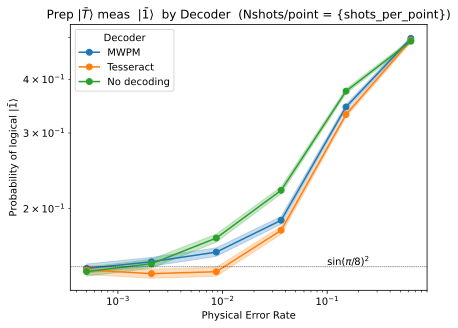

In [245]:
# Minimum-weight perfect matching (MWPM) via sinter's built-in pymatching decoder.
mwpm_stats = sinter.collect(
    num_workers=1,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=shots_per_point,
    max_errors=shots_per_point,
    start_batch_size=shots_per_point,
    max_batch_size=shots_per_point,
)

def curve(stats, decoder_name):
    pts = [(s.json_metadata["p"], s.errors, s.shots) for s in stats if s.decoder == decoder_name]
    pts.sort()
    x = np.array([p for p, _, _ in pts])
    y = np.array([n / N for _, n, N in pts])
    err = np.array([stat_err(n, N) for _, n, N in pts])
    return x, y, err

fig, ax = plt.subplots(1, 1)
all_stats = collected_stats + mwpm_stats
label_map = {"pymatching": "MWPM", "tesseract": "Tesseract", "no decoding": "No decoding"}
for decoder_name, label in label_map.items():
    x, y, err = curve(all_stats, decoder_name)
    if len(x) == 0:
        continue
    line, = ax.plot(x, y, marker="o", label=label)
    ax.fill_between(x, y - err, y + err, alpha=0.25, color=line.get_color())

ax.loglog()
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel(r"Probability of logical $|\bar{1}\rangle$")
ax.set_title(r"Prep $|\bar{T}\rangle$ meas  $|\bar{1}\rangle$  by Decoder  (Nshots/point = {shots_per_point})")
ax.axhline(np.sin(np.pi / 8) ** 2, color="k", linestyle="--", lw=0.4)
ax.text(0.1, np.sin(np.pi / 8) ** 2 * 1.01, r"$\sin(\pi/8)^2$", fontsize=10)
ax.legend(title="Decoder");


The Verdict:

The flattening of the curves in the bottom graph is the ultimate proof that your decoders are succeeding. They are effectively stripping away the physical hardware noise, allowing the true, underlying quantum distribution of your injected magic state ($14.64\%$ chance of 1) to shine through perfectly.